## **STEP 0** - SETUP

In [ ]:
!pip install ultralytics
!pip install kaggle
!kaggle datasets list -s spacenet

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")


## **STEP 1** - DATASET

In [11]:
mkdir -p ~/.kaggle && echo KGAT_633a9619420f8366b5a1d651d662e4de > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [12]:
!kaggle datasets list -s spacenet

ref                                                          title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
amerii/spacenet-7-multitemporal-urban-development            Spacenet 7 Multi-Temporal Urban Development         11096013398  2020-11-15 00:14:09.010000           5804         74                1  
razaimam45/spacenet-an-optimally-distributed-astronomy-data  SpaceNet: A Comprehensive Astronomical Dataset      56552989870  2024-08-30 01:00:24.993000           1129         18            0.875  
sandhiwangiyana/spacenet-6-multisensor-allweather-mapping    SpaceNet 6 Multi-Sensor All-Weather Mapping         41904026651  2021-03-27 23:12:21.753000           4809         29           0.9375  
amerii/spa

In [13]:
!kaggle datasets download -d pallav23/icg-spacenet-sandox-yolo

Dataset URL: https://www.kaggle.com/datasets/pallav23/icg-spacenet-sandox-yolo
License(s): CC-BY-SA-4.0
100% 950M/950M [00:58<00:00, 17.0MB/s]



In [14]:
!unzip -q icg-spacenet-sandox-yolo.zip

In [15]:
!ls

icg-spacenet-sandox-yolo.zip  sample_data  spacenet_buildings_yolo  yolov8s.pt


Getting the structure in which the dataset is stored

In [18]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    if len(files) > 0:
        print(root)
        print("Files:", len(files))
        print("-"*40)


.
Files: 2
----------------------------------------
./.config
Files: 8
----------------------------------------
./.config/logs/2026.06.04
Files: 6
----------------------------------------
./.config/configurations
Files: 1
----------------------------------------
./spacenet_buildings_yolo
Files: 2
----------------------------------------
./spacenet_buildings_yolo/labels
Files: 1148
----------------------------------------
./spacenet_buildings_yolo/images
Files: 1148
----------------------------------------
./sample_data
Files: 6
----------------------------------------


listing to understand how the files/images are named

In [19]:
!ls spacenet_buildings_yolo/images | head
!ls spacenet_buildings_yolo/labels | head

AOI_3_Paris_img1000.png
AOI_3_Paris_img1001.png
AOI_3_Paris_img1003.png
AOI_3_Paris_img1007.png
AOI_3_Paris_img1008.png
AOI_3_Paris_img1009.png
AOI_3_Paris_img100.png
AOI_3_Paris_img1010.png
AOI_3_Paris_img1011.png
AOI_3_Paris_img1012.png
AOI_3_Paris_img1000.txt
AOI_3_Paris_img1001.txt
AOI_3_Paris_img1003.txt
AOI_3_Paris_img1007.txt
AOI_3_Paris_img1008.txt
AOI_3_Paris_img1009.txt
AOI_3_Paris_img100.txt
AOI_3_Paris_img1010.txt
AOI_3_Paris_img1011.txt
AOI_3_Paris_img1012.txt


getting the content of the first file

In [21]:
import os

label_file = os.listdir("spacenet_buildings_yolo/labels")[0]

with open(f"spacenet_buildings_yolo/labels/{label_file}") as f:
    content= f.read()

print(content)
print("Length:", len(content))
print("Content:", repr(content))


Length: 0
Content: ''


we find the first file is empty- no buildings in the first image

In [23]:
import os

for label_file in os.listdir("spacenet_buildings_yolo/labels"):
    path = f"spacenet_buildings_yolo/labels/{label_file}"

    if os.path.getsize(path) > 0:
        print(label_file)
        break

AOI_3_Paris_img196.txt


printing the content of the first non empty image

In [24]:
with open(f"spacenet_buildings_yolo/labels/{label_file}") as f:
    print(f.read())


0 0.729077 0.435285 0.233600 0.149215
0 0.715269 0.532808 0.055677 0.031985
0 0.130754 0.210046 0.261508 0.205262
0 0.937254 0.962623 0.120015 0.074754
0 0.854754 0.609085 0.137415 0.083615
0 0.087123 0.959208 0.174246 0.081585


adding bounding boxed to the buildings in the first image , as an example

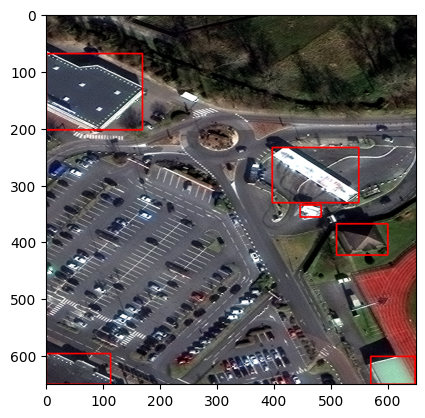

In [28]:
import cv2
import matplotlib.pyplot as plt

img_name = "AOI_3_Paris_img196.png"

img_path = f"spacenet_buildings_yolo/images/{img_name}"
label_path = f"spacenet_buildings_yolo/labels/AOI_3_Paris_img196.txt"

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

with open(label_path) as f:
    for line in f:
        cls, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)

        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)


plt.imshow(img)

plt.show()

# **STEP 2** - UNDERSTANDING THE DATASET

## **2.1** - Counting images





In [26]:
import os

num_images = len(os.listdir("spacenet_buildings_yolo/images"))
num_labels = len(os.listdir("spacenet_buildings_yolo/labels"))

print("Images:", num_images)
print("Labels:", num_labels)

Images: 1148
Labels: 1148


## **2.2** - Displaying 9 images with buildings bounded with boxes

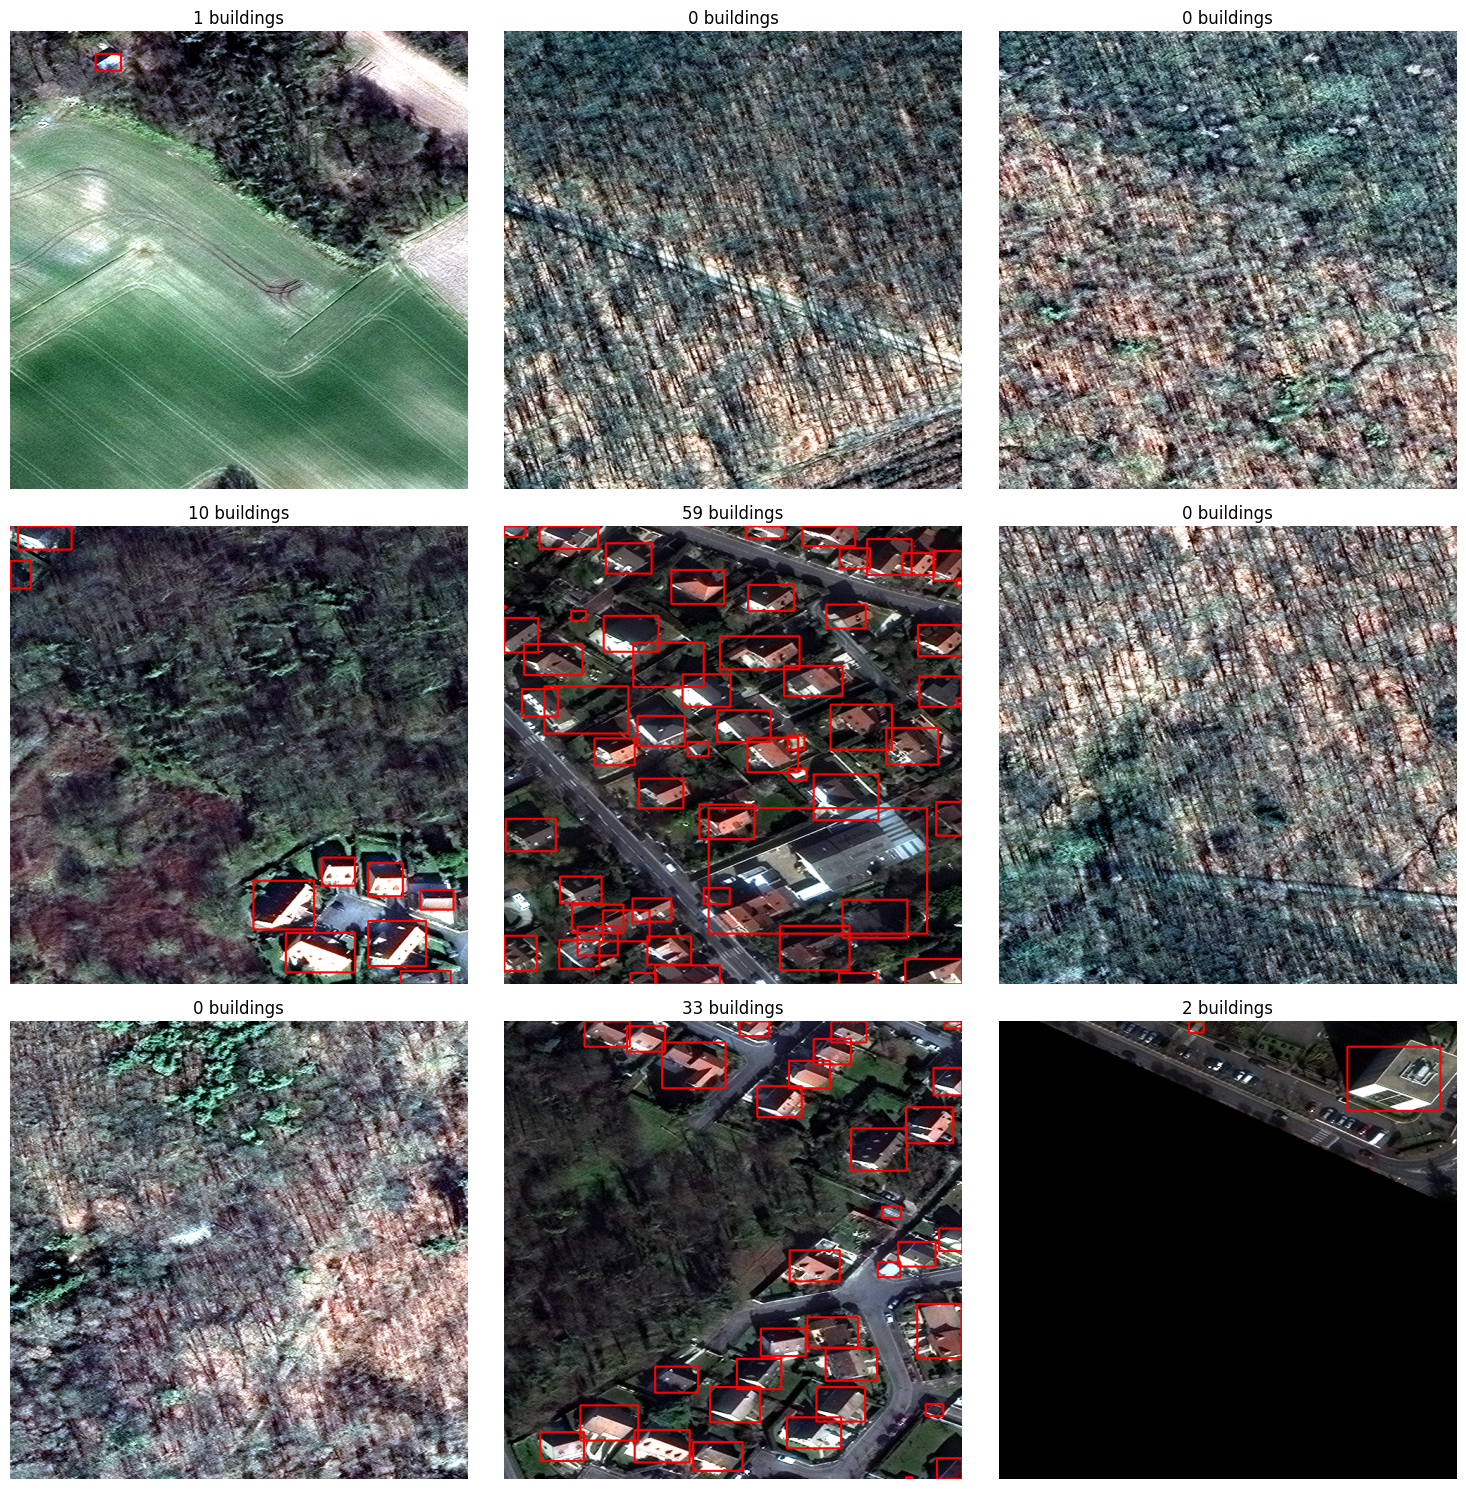

In [29]:
import os
import random
import cv2
import matplotlib.pyplot as plt

images_dir = "spacenet_buildings_yolo/images"
labels_dir = "spacenet_buildings_yolo/labels"

sample_images = random.sample(
    os.listdir(images_dir),
    9
)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, img_name in zip(axes.flatten(), sample_images):

    img_path = os.path.join(images_dir, img_name)
    label_path = os.path.join(
        labels_dir,
        img_name.replace(".png", ".txt")
    )

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    building_count = 0

    if os.path.exists(label_path):

        with open(label_path) as f:

            lines = f.readlines()
            building_count = len(lines)

            for line in lines:

                cls, x, y, bw, bh = map(
                    float,
                    line.strip().split()
                )

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)

                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(
                    img,
                    (x1, y1),
                    (x2, y2),
                    (255, 0, 0),
                    2
                )

    ax.imshow(img)
    ax.set_title(f"{building_count} buildings")
    ax.axis("off")

plt.tight_layout()
plt.show()

## **2.3** - Average number of buildings per image

In [27]:
import os

total_buildings = 0

for file in os.listdir("spacenet_buildings_yolo/labels"):
    with open(f"spacenet_buildings_yolo/labels/{file}") as f:
        total_buildings += len(f.readlines())

avg_buildings = total_buildings / len(os.listdir("spacenet_buildings_yolo/labels"))

print("Total Buildings:", total_buildings)
print("Average Buildings/Image:", avg_buildings)

Total Buildings: 16633
Average Buildings/Image: 14.488675958188153


TOTAL BUILDINGS : 16633  
AVERAGE BUILDINGS/IMAGE: 14.488675958188153

**Size and Quality consistency**  
The overal dimensions of the images are almost same which helps the model learn feautures more effectively , however in many images 70-80% of screen is covered in plain black and the satellite image is as well disoriented.               
And the quality of the images is mostly consistent but the low resolution and the rugged terrain/texture in few images, the shadows, other objects resembles to buildings, which may train the model to be more robust but at the same time can also generate false positives in testing phase.

**Challenges the model might face**       
Some images have disoriented satellite imagery with 70-80% covered in plain black also containing sharp edges.Due to low resolution there are lot of misleading disturbances like shadows, terrain , and also becomes harder to  differentiate structures which resemble a roof of a building but are not buildings like sheds, parking lots, vehicles etc, And in some there are partial images of buildings with cut out and partial shapes of the buildings, the low resoultion and dense clusters in images where its difficult to differentiate the structure of a building from the surrounding.Very small buildings etc

# **STEP-3**- Preparation



## Splitting dataset

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

base_dir = "spacenet_buildings_yolo"

images_dir = os.path.join(base_dir, "images")
labels_dir = os.path.join(base_dir, "labels")

all_images = [
    f for f in os.listdir(images_dir)
    if f.endswith(".png")
]

# 80% train, 20% temp
train_files, temp_files = train_test_split(
    all_images,
    test_size=0.2,
    random_state=42
)

# Split remaining 20% into 10% val + 10% test
val_files, test_files = train_test_split(
    temp_files,
    test_size=0.5,
    random_state=42
)

# Create folders
for split in ["train", "val", "test"]:

    os.makedirs(
        os.path.join(base_dir, "images", split),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(base_dir, "labels", split),
        exist_ok=True
    )


def move_files(file_list, split):

    for img_file in file_list:

        label_file = img_file.replace(".png", ".txt")

        shutil.move(
            os.path.join(images_dir, img_file),
            os.path.join(base_dir, "images", split, img_file)
        )

        shutil.move(
            os.path.join(labels_dir, label_file),
            os.path.join(base_dir, "labels", split, label_file)
        )


move_files(train_files, "train")
move_files(val_files, "val")
move_files(test_files, "test")

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

## Verification

In [33]:
for split in ["train", "val", "test"]:

    print("\n", split.upper())

    print(
        "Images:",
        len(os.listdir(f"spacenet_buildings_yolo/images/{split}"))
    )

    print(
        "Labels:",
        len(os.listdir(f"spacenet_buildings_yolo/labels/{split}"))
    )


 TRAIN
Images: 918
Labels: 918

 VAL
Images: 115
Labels: 115

 TEST
Images: 115
Labels: 115


##dataset.yaml

In [34]:
yaml_content = """
path: /content/spacenet_buildings_yolo

train: images/train
val: images/val
test: images/test

nc: 1

names:
  0: building
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_content)



## verification

In [35]:
with open("dataset.yaml") as f:
    print(f.read())


path: /content/spacenet_buildings_yolo

train: images/train
val: images/val
test: images/test

nc: 1

names:
  0: building



# **STEP 4** TRAINING YOLO v8


 YOLOv8s is initialized with pre-trained weights (yolov8s.pt) instead of random weights because it has already learned useful visual features from a large dataset. This allows faster convergence, better performance with limited data, and significantly reduces training time compared to training from scratch.

## **4.2** TRAINING YOLO

In [36]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data="dataset.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    project="runs/detect",
    name="building_detector"
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=building_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

Printing the final 5

In [38]:
!find . -name results.csv

./runs/detect/runs/detect/building_detector/results.csv


In [40]:
import pandas as pd

results_csv = pd.read_csv(
    "runs/detect/runs/detect/building_detector/results.csv"
)

results_csv.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
15,16,421.845,1.32051,0.81232,1.18127,0.81288,0.72448,0.80333,0.48205,1.32350,0.83120,1.20800,0.000515,0.000515,0.000515
16,17,446.607,1.29142,0.79409,1.17015,0.79718,0.73397,0.80043,0.47447,1.33476,0.84835,1.21475,0.000416,0.000416,0.000416
17,18,471.225,1.27920,0.78383,1.14996,0.81867,0.73024,0.81188,0.48302,1.33042,0.81608,1.21809,0.000317,0.000317,0.000317
18,19,495.290,1.26785,0.75408,1.14711,0.82888,0.72672,0.81376,0.49068,1.31572,0.80834,1.20385,0.000218,0.000218,0.000218
19,20,521.735,1.26160,0.74270,1.14489,0.84227,0.72370,0.81570,0.49371,1.30744,0.79128,1.19701,0.000119,0.000119,0.000119


Printing final box_loss and mAP50

In [41]:
final_box_loss = results_csv["train/box_loss"].iloc[-1]
final_map50 = results_csv["metrics/mAP50(B)"].iloc[-1]

print("Final Box Loss:", final_box_loss)
print("Final mAP50:", final_map50)

Final Box Loss: 1.2616
Final mAP50: 0.8157


##**4.3** Plotting training graphs

**Train vs Val Box Loss**

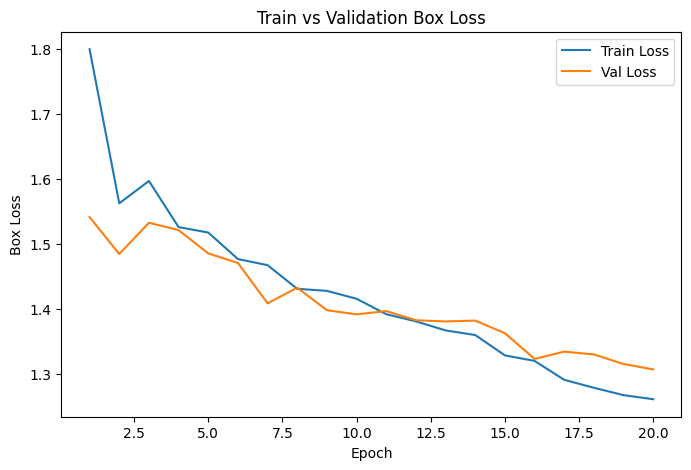

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results_csv["epoch"],
    results_csv["train/box_loss"],
    label="Train Loss"
)

plt.plot(
    results_csv["epoch"],
    results_csv["val/box_loss"],
    label="Val Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.title("Train vs Validation Box Loss")
plt.legend()

plt.show()

The validation loss closely followed the training loss throughout training, indicating that the model generalized well and did not exhibit significant overfitting.

**mAP@50 Curve**

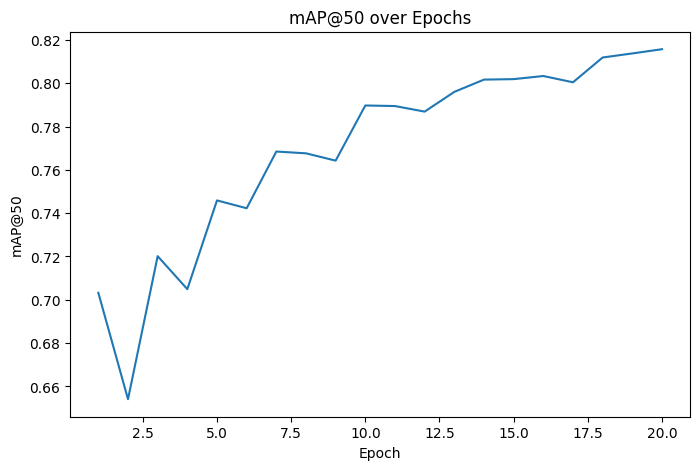

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    results_csv["epoch"],
    results_csv["metrics/mAP50(B)"]
)

plt.xlabel("Epoch")
plt.ylabel("mAP@50")
plt.title("mAP@50 over Epochs")

plt.show()

The mAP@50 improved rapidly during the initial epochs and then plateaued, suggesting that the model had largely converged.

#**STEP 5** - EVALUATION

In [44]:
metrics = model.val(
    data="dataset.yaml",
    split="test"
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2708.0±1434.6 MB/s, size: 976.5 KB)
val: Scanning /content/spacenet_buildings_yolo/labels/test... 115 images, 52 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 257.6it/s 0.4s
val: New cache created: /content/spacenet_buildings_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.4it/s 5.5s
                   all        115       1775      0.819      0.724      0.798      0.494
Speed: 6.4ms preprocess, 12.1ms inference, 0.0ms loss, 5.4ms postprocess per image
Results saved to /content/runs/detect/val


Extracting metric

In [45]:
precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50

f1 = 2 * precision * recall / (precision + recall)

print("mAP50:", map50)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

mAP50: 0.798013165918079
Precision: 0.8189388060734949
Recall: 0.723943661971831
F1 Score: 0.7685168124967874


| **METRIC** | **Value** | **What it means** |
|------------|------------------|--------------------------------------|
| mAP50| 0.798 | it was able to detect and localize buildings with about 80% overall detection quality when predictions were considered correct at 50% bounding-box overlap|
|Precision| 0.819 | 82% of predicted buildings were actually buildings|
|Recall| 0.724 | 72% of all true buildings were detected|
|F1 Score| 0.769 | 77% being the combined measure of Precision and Recall|

##Precision - Recall curve

In [50]:
!find runs -type f

runs/detect/runs/detect/building_detector/confusion_matrix.png
runs/detect/runs/detect/building_detector/val_batch0_pred.jpg
runs/detect/runs/detect/building_detector/val_batch1_labels.jpg
runs/detect/runs/detect/building_detector/train_batch0.jpg
runs/detect/runs/detect/building_detector/val_batch2_pred.jpg
runs/detect/runs/detect/building_detector/train_batch582.jpg
runs/detect/runs/detect/building_detector/BoxPR_curve.png
runs/detect/runs/detect/building_detector/train_batch581.jpg
runs/detect/runs/detect/building_detector/confusion_matrix_normalized.png
runs/detect/runs/detect/building_detector/results.png
runs/detect/runs/detect/building_detector/val_batch1_pred.jpg
runs/detect/runs/detect/building_detector/BoxP_curve.png
runs/detect/runs/detect/building_detector/args.yaml
runs/detect/runs/detect/building_detector/val_batch2_labels.jpg
runs/detect/runs/detect/building_detector/train_batch2.jpg
runs/detect/runs/detect/building_detector/train_batch580.jpg
runs/detect/runs/detect/bui

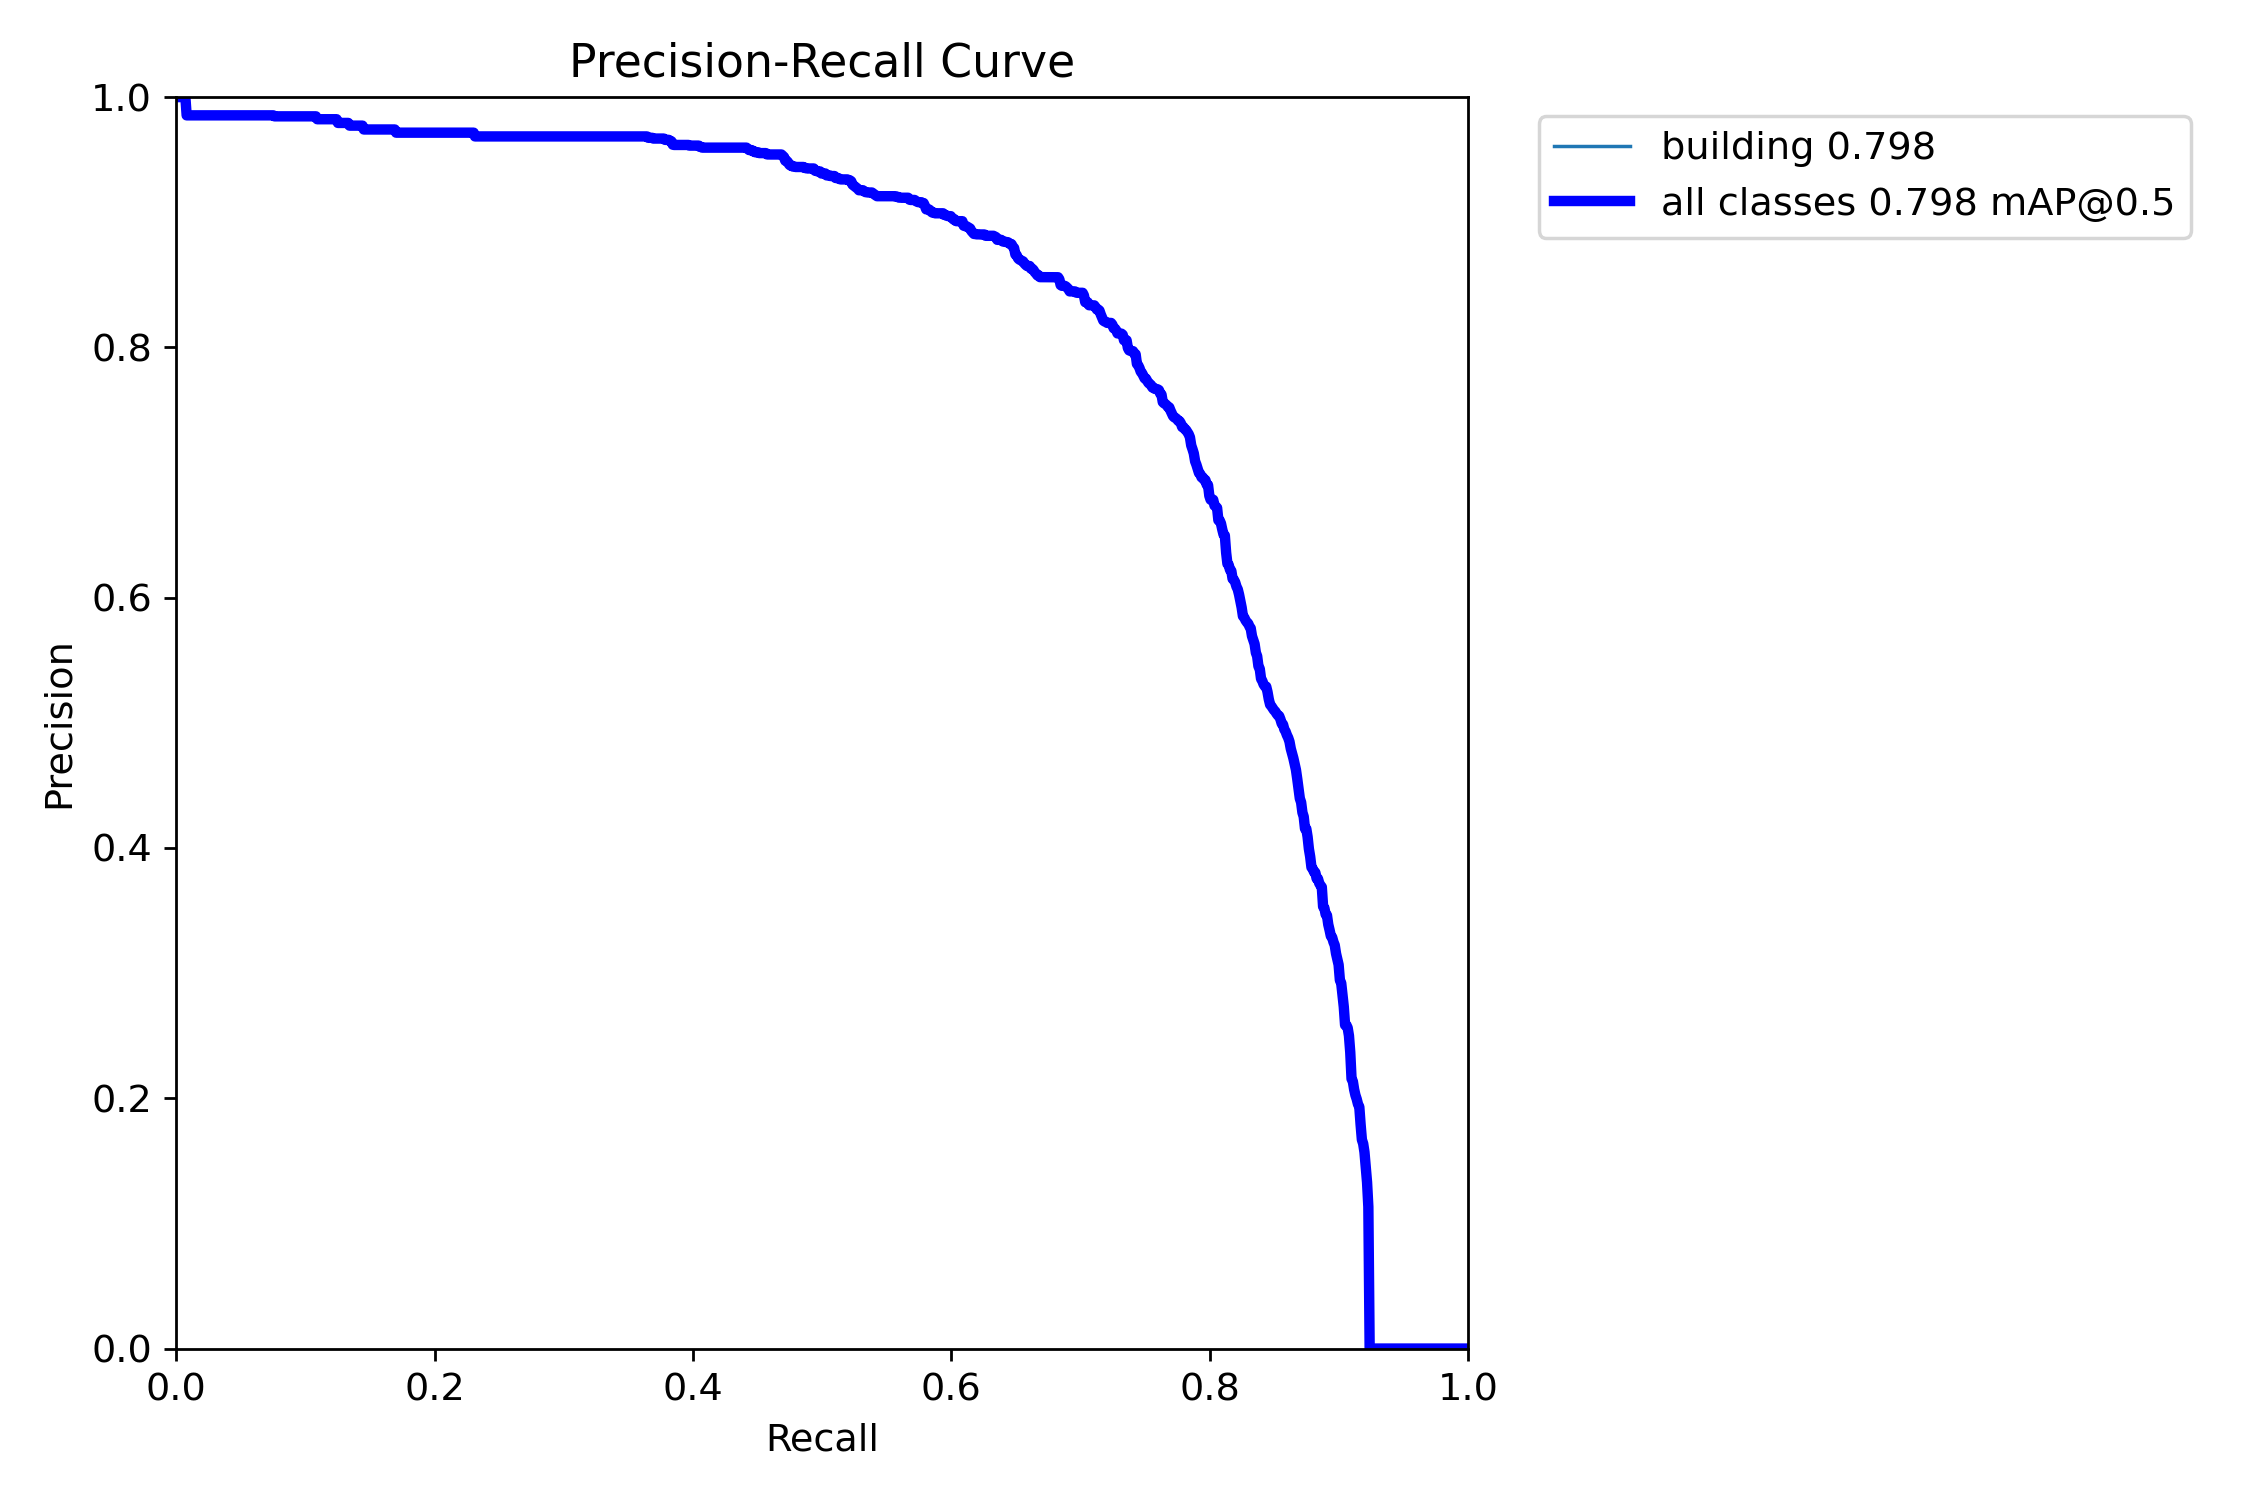

In [51]:
from IPython.display import Image

Image("runs/detect/val/BoxPR_curve.png")

##Confusion Matrix

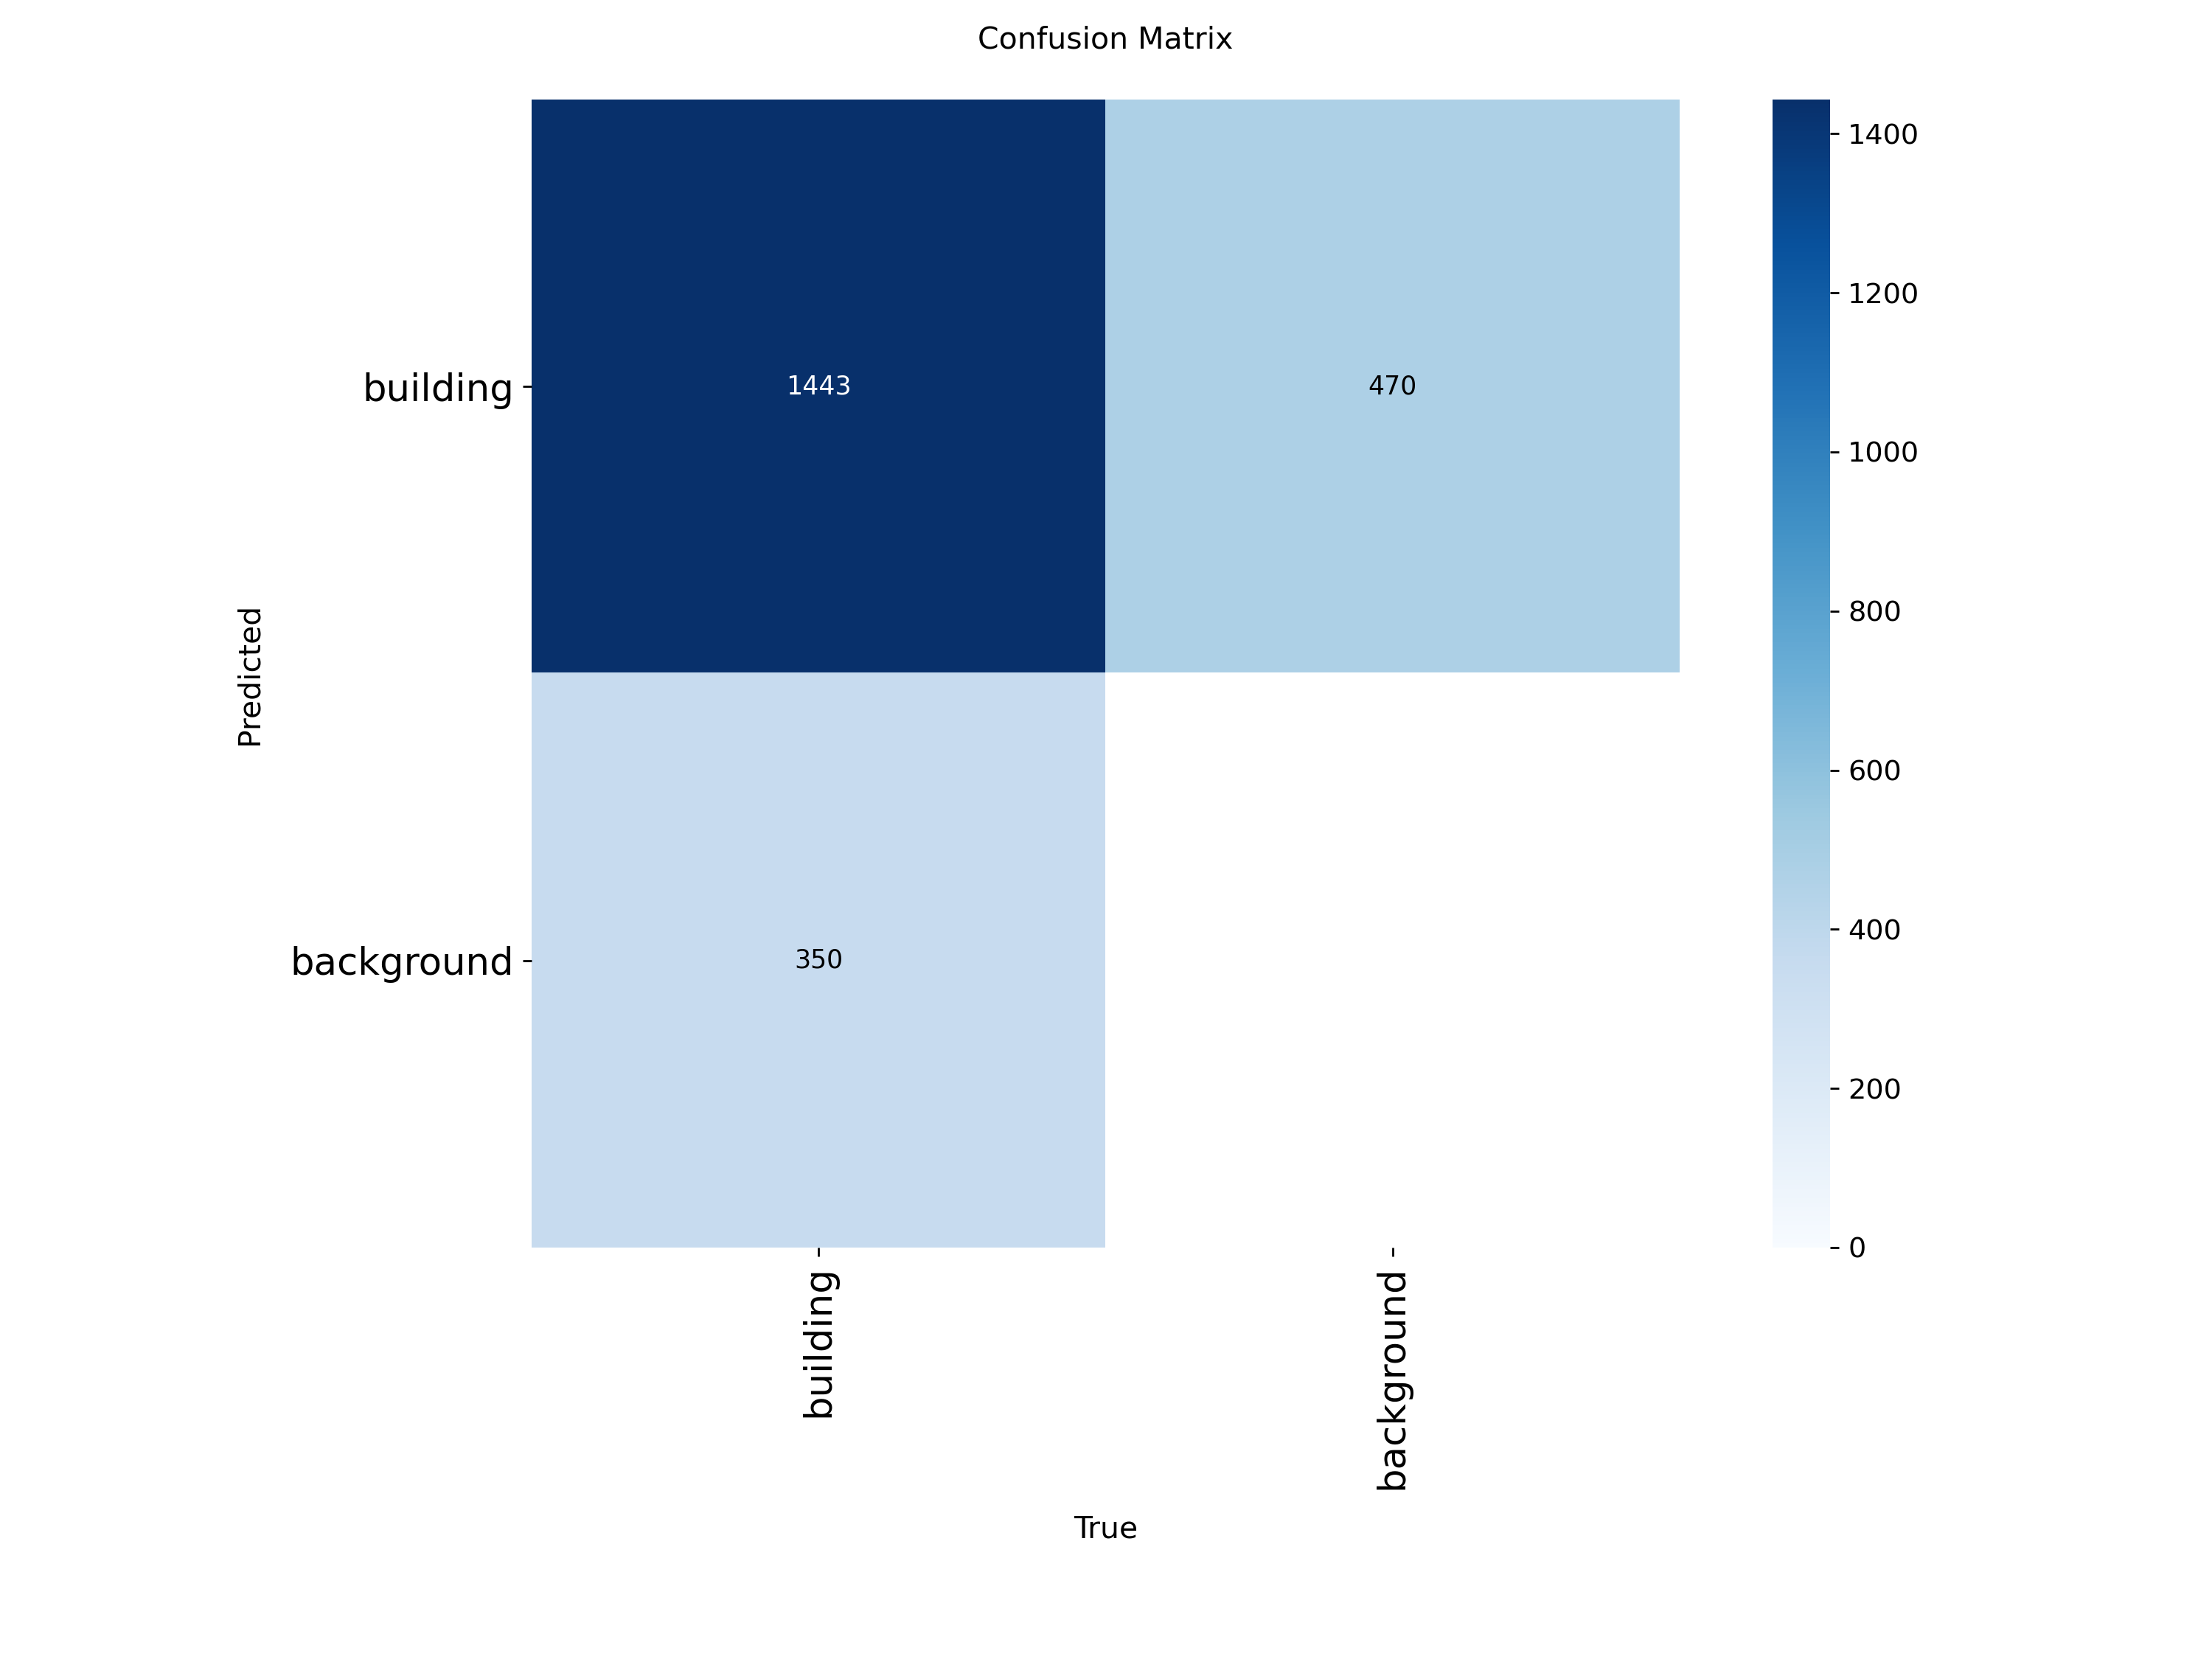

In [53]:
from IPython.display import Image

Image("runs/detect/runs/detect/building_detector/confusion_matrix.png")

#**STEP 6** - BUILDING THE PIPELINE

##**6.1**

###Testing it on 10 images

Selecting

In [64]:
from ultralytics import YOLO
import cv2
import numpy as np
import os
import random

model = YOLO("runs/detect/runs/detect/building_detector/weights/best.pt")

def detect_buildings(image_path):

    results = model.predict(
        image_path,
        conf=0.25,
        verbose=False
    )

    result = results[0]

    building_count = len(result.boxes)

    confidences = result.boxes.conf.cpu().numpy()

    avg_confidence = (
        np.mean(confidences)
        if len(confidences) > 0
        else 0
    )

    return building_count, avg_confidence


test_images_dir = "spacenet_buildings_yolo/images/test"
test_labels_dir = "spacenet_buildings_yolo/labels/test"

empty_images = []
non_empty_images = []

for img in os.listdir(test_images_dir):

    label_path = os.path.join(
        test_labels_dir,
        img.replace(".png", ".txt")
    )

    with open(label_path) as f:
        count = len(f.readlines())

    if count == 0:
        empty_images.append(img)
    else:
        non_empty_images.append(img)

sample_images = (
    random.sample(non_empty_images, 8)
    + random.sample(empty_images, 2)
)

random.shuffle(sample_images)

print("Selected Images:\n")


for img in sample_images:

    count, conf = detect_buildings(
        os.path.join(test_dir, img)
    )

    print(img)
    print("Buildings:", count)
    print("Avg Confidence:", round(conf, 3))
    print()

Selected Images:

AOI_3_Paris_img338.png
Buildings: 0
Avg Confidence: 0

AOI_3_Paris_img1270.png
Buildings: 18
Avg Confidence: 0.526

AOI_3_Paris_img118.png
Buildings: 28
Avg Confidence: 0.53

AOI_3_Paris_img359.png
Buildings: 46
Avg Confidence: 0.602

AOI_3_Paris_img1546.png
Buildings: 18
Avg Confidence: 0.535

AOI_3_Paris_img85.png
Buildings: 5
Avg Confidence: 0.489

AOI_3_Paris_img1388.png
Buildings: 0
Avg Confidence: 0

AOI_3_Paris_img1089.png
Buildings: 52
Avg Confidence: 0.588

AOI_3_Paris_img961.png
Buildings: 67
Avg Confidence: 0.639

AOI_3_Paris_img480.png
Buildings: 54
Avg Confidence: 0.56



Generating True and Predicted Counts

In [67]:
true_counts = []
pred_counts = []

for img in sample_images:

    # True count from labels
    label_path = os.path.join(
        test_labels_dir,
        img.replace(".png", ".txt")
    )

    with open(label_path) as f:
        true_count = len(f.readlines())

    # Predicted count from model
    pred_count, _ = detect_buildings(
        os.path.join(test_images_dir, img)
    )

    true_counts.append(true_count)
    pred_counts.append(pred_count)

    print(
        f"{img}: True={true_count}, Predicted={pred_count}"
    )

AOI_3_Paris_img338.png: True=0, Predicted=0
AOI_3_Paris_img1270.png: True=13, Predicted=18
AOI_3_Paris_img118.png: True=32, Predicted=28
AOI_3_Paris_img359.png: True=45, Predicted=46
AOI_3_Paris_img1546.png: True=17, Predicted=18
AOI_3_Paris_img85.png: True=2, Predicted=5
AOI_3_Paris_img1388.png: True=0, Predicted=0
AOI_3_Paris_img1089.png: True=44, Predicted=52
AOI_3_Paris_img961.png: True=66, Predicted=67
AOI_3_Paris_img480.png: True=47, Predicted=54


###Bar chart

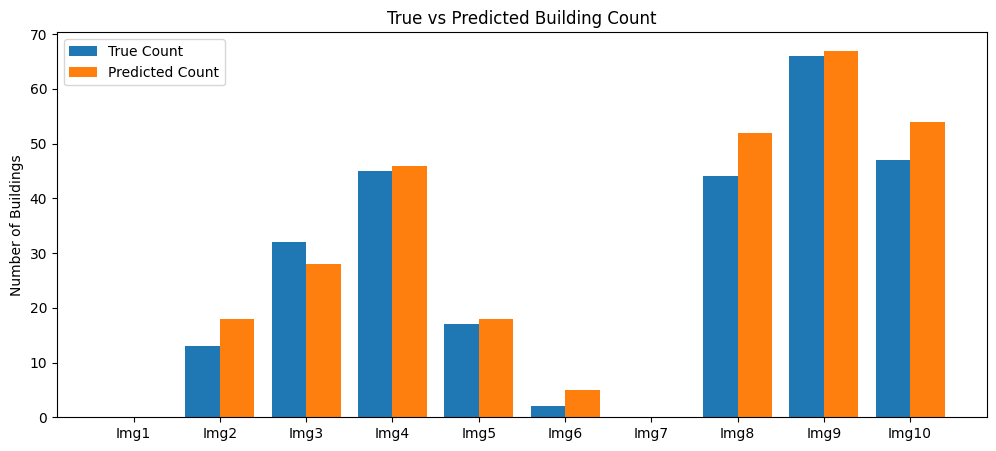

In [68]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(sample_images))

plt.figure(figsize=(12,5))

plt.bar(
    x - 0.2,
    true_counts,
    width=0.4,
    label="True Count"
)

plt.bar(
    x + 0.2,
    pred_counts,
    width=0.4,
    label="Predicted Count"
)

plt.xticks(
    x,
    [f"Img{i+1}" for i in range(10)]
)

plt.ylabel("Number of Buildings")
plt.title("True vs Predicted Building Count")
plt.legend()

plt.show()

###Mean Absolute Error

In [69]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    true_counts,
    pred_counts
)

print("Mean Absolute Error:", round(mae, 2))

Mean Absolute Error: 3.0


## **6.2** Pipeline

In [75]:
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def building_pipeline(image_path):

    start_time = time.time()

    results = model.predict(
        image_path,
        conf=0.25,
        verbose=False
    )

    result = results[0]

    processing_time = (
        time.time() - start_time
    ) * 1000

    building_count = len(result.boxes)

    confidences = result.boxes.conf.cpu().numpy()

    avg_confidence = (
        np.mean(confidences)
        if len(confidences) > 0
        else 0
    )

    original = cv2.imread(image_path)
    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    annotated = result.plot()

    plt.figure(figsize=(12,6))

    plt.subplot(1,2,1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(annotated)
    plt.title("Detected Buildings")
    plt.axis("off")

    plt.show()

    print(f"Image: {os.path.basename(image_path)}")
    print(f"Buildings detected: {building_count}")
    print(f"Avg confidence: {avg_confidence:.2f}")
    print(f"Processing time: {processing_time:.1f} ms")





TESTING IT

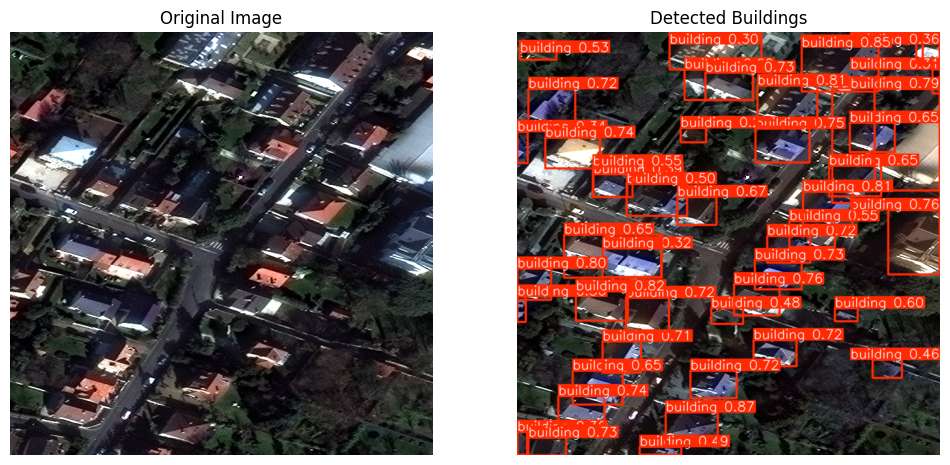

Image: AOI_3_Paris_img359.png
Buildings detected: 46
Avg confidence: 0.60
Processing time: 38.7 ms


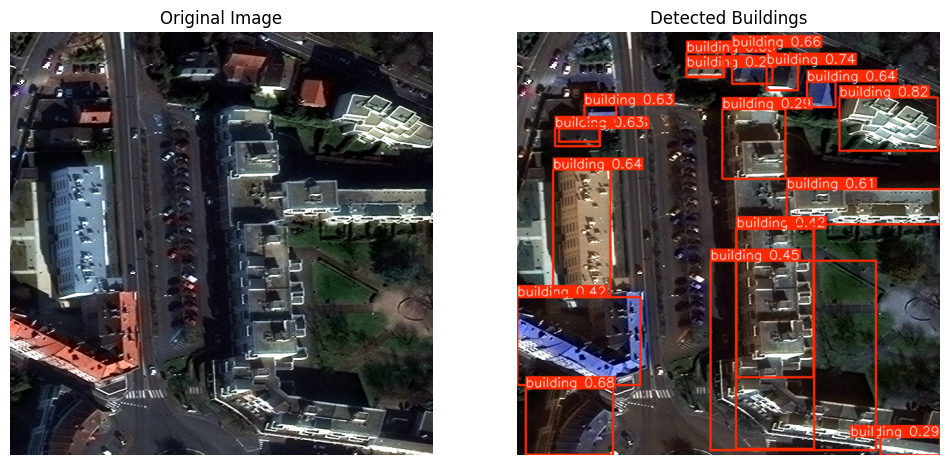

Image: AOI_3_Paris_img1270.png
Buildings detected: 18
Avg confidence: 0.53
Processing time: 36.8 ms


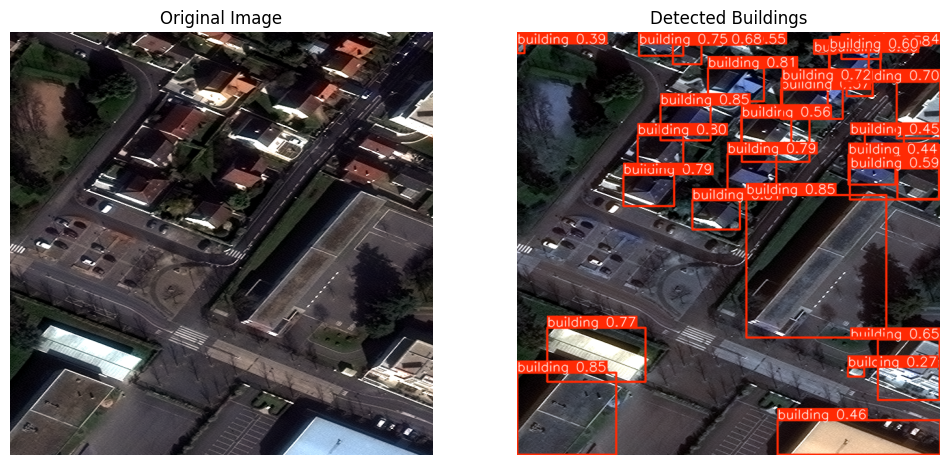

Image: AOI_3_Paris_img354.png
Buildings detected: 31
Avg confidence: 0.60
Processing time: 45.8 ms


In [76]:
final_images = random.sample(
    non_empty_images,
    3
)

for img in final_images:

    building_pipeline(
        os.path.join(
            test_images_dir,
            img
        )
    )